In [1]:
import json
import pandas as pd
import numpy as np
import nibabel as nib
from pycirclize import Circos
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

In [2]:
def load_dict_from_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [ ]:
dist_feats='./data/results/Reading_SES_DistanceCentroid_cpm_analysis/ds_permed0000_stable.json'
fc_feats='./data/results/Reading_SES_FC_cpm_analysis/ds_permed0000_stable.json'
dist_feats=load_dict_from_json(dist_feats)
fc_feats=load_dict_from_json(fc_feats)

## separate positive and negative feats
dist_pos=dist_feats['ReadEng_Unadj']['positive']
dist_neg=dist_feats['ReadEng_Unadj']['negative']

fc_pos=fc_feats['ReadEng_Unadj']['positive']
fc_neg=fc_feats['ReadEng_Unadj']['negative']


#### break features apart by hemisphere
Lpos_dist = [i for i in dist_pos if "LH" in i]
Rpos_dist = [i for i in dist_pos if "RH" in i]
Lneg_dist = [i for i in dist_neg if "LH" in i]
Rneg_dist = [i for i in dist_neg if "RH" in i]


LposFC = [i for i in fc_pos if "LH" in i]
RposFC = [i for i in fc_pos if "RH" in i]
LnegFC = [i for i in fc_neg if "LH" in i]
RnegFC = [i for i in fc_neg if "RH" in i]

In [4]:
def remat(data, pos, neg):
    """function which takes positive and negative edges from each hemisphere.
    puts them back into matrix form"""
    data = data.copy()
    data.loc[:, :] = 0
    data[pos] = 1
    data[neg] = -1
    vect = data.iloc[0].values
    mat = np.zeros((200, 200))
    mat[np.triu_indices(200, k=1)] = vect
    mat[np.tril_indices(200, k=-1)] = mat.T[np.tril_indices(200, k=-1)]
    return mat

In [5]:
def prepare_SchaeferSectors(Schaefer, mat_dist, hemi, alt_parcellation=False):
    #### where alt parcellation is the dictioary loaded from a cifti file
    if alt_parcellation == False:
        if hemi == "L":
            splitt = "_LH_"
        else:
            splitt = "_RH_"
        # Extract network labels from the dictionary keys
        labels = [key.split(splitt)[1].split("_")[0] for key in Schaefer.keys()]
    else:
        relabel = map_schaefer_to_other(Schaefer, alt_parcellation)
        labels = list(relabel.values())
    # Identify unique networks and their counts
    net, arrays = np.unique(labels, return_counts=True)

    # Create a dictionary for sectors with network names and their counts
    sectors = dict(zip(net, arrays))

    # Create a DataFrame for the connectivity matrix
    mat_df = pd.DataFrame(mat_dist, index=labels, columns=labels)

    return sectors, mat_df

In [61]:
def generate_circos_plot(mat_df, sectors, name2color, half=False,filepath=None):
    """
    Generate a Circos plot for given matrix data.

    """

    # Initialize the Circos plot with a specified space between sectors
    if half == False:
        circos = Circos(sectors, space=2, start=0, end=360)
    elif half == "L":
        circos = Circos(sectors, space=2, start=180, end=360)
    elif half == "R":
        sectors = OrderedDict(reversed(list(sectors.items())))
        circos = Circos(sectors, space=2, end=180)

    # Configure sectors without labels
    for sector in circos.sectors:
        track = sector.add_track((95, 100))
        track.axis(fc=name2color[sector.name])
        # track.text(sector.name, color="black", size=10,r=105)
        # sector.text(sector.name, r=62)

    # Iterate over non-zero matrix entries
    x, y = np.where(mat_df != 0)
    for i, j in zip(x, y):
        val = mat_df.iloc[i, j]
        row_name = mat_df.index[i]
        column_name = mat_df.columns[j]

        # Normalize the indices relative to their sectors
        row_index_normalized = i % sectors[row_name]
        col_index_normalized = j % sectors[column_name]

        # Determine color based on the value
        color = "red" if val > 0 else "blue"

        # Link the sectors using normalized indices
        circos.link_line(
            (row_name, row_index_normalized),
            (column_name, col_index_normalized),
            direction=1,
            color=color,
            arrow_height=0,
            arrow_width=0,
            lw=1.5,
            alpha=0.5,
        )

    # Generate and display the plot
    fig = circos.plotfig()
    if filepath is not None:
        fig.tight_layout(pad=0)
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.savefig(f"{filepath}.png", dpi=600, bbox_inches="tight",pad_inches=0,transparent=True)

def plot_heatmap(data, label_to_color,filepath=None):
    """Plot data as a heatmaps"""
    mat = data.values
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(mat, cmap="bwr")

    # Set up grid lines
    indices = data.index
    grid = []
    lines = 0
    tick_positions = []  # Positions for network labels
    index_labels = data.columns
    # Set up grid lines
    indices = Counter(index_labels)
    for label, count in indices.items():
        lines += count
        grid.append(lines - 0.5)
        tick_positions.append(
            lines - count / 2
        )  # Position labels in the center of their blocks
    ax.set_xticks(grid, minor=False)
    ax.set_yticks(grid, minor=False)
    ax.grid(which="minor", color="slategray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", size=0)

    # Create an array for the side and bottom color bars
    color_bar_side = np.zeros((200, 1, 4))
    color_bar_bottom = np.zeros((1, 200, 4))
    for idx, label in enumerate(index_labels):
        rgba_color = matplotlib.colors.to_rgba(label_to_color[label])
        color_bar_side[idx, 0, :] = rgba_color
        color_bar_bottom[0, idx, :] = rgba_color

    # Get the exact dimensions of the imshow axes
    bbox = ax.get_position()
    ax_side = fig.add_axes([bbox.x0 - 0.025, bbox.y0, 0.02, bbox.height])
    ax_bottom = fig.add_axes([bbox.x0, bbox.y0 - 0.025, bbox.width, 0.02])

    # Plot the color bars
    ax_side.imshow(color_bar_side, aspect="auto")
    ax_side.set_yticks(tick_positions)
    ax_side.set_yticklabels("")
    ax_side.yaxis.set_label_position("left")
    ax_side.set_xticks([])

    ax_bottom.imshow(color_bar_bottom, aspect="auto")
    ax_bottom.set_xticks(tick_positions)
    ax_bottom.set_xticklabels([])
    ax_bottom.set_yticklabels([])

    # Remove any potential extra ticks
    ax_bottom.set_xticks([])
    ax_bottom.set_yticks([])

    # Remove spines to avoid lines around the colorbar
    for spine in ax_side.spines.values():
        spine.set_visible(False)
    for spine in ax_bottom.spines.values():
        spine.set_visible(False)

    # Remove main heatmap ticks and labels
    ax.set_xticklabels("")
    ax.set_yticklabels("")
    if filepath is not None:
        fig.savefig(f"{filepath}.png", dpi=600, bbox_inches="tight",transparent=True)

In [62]:
rsn_colors = {
    "Vis": "#a252ad",
    "SomMot": "#789ac0",
    "Limbic": "#f6fdc9",
    "SalVentAttn": "#e065fe",
    "DorsAttn": "#409832",
    "Cont": "#f0b943",
    "Default": "#d8717c",
}

In [63]:
### load the atlas label dictionary
from surfdist.load import (load_cifti_labels)  ## surfdist from fork: https://github.com/neurabenn/surfdist
LSchaefer = load_cifti_labels("./brain2behaviour/atlases/schaefer/Schaefer2018_400Parcels_7Networks_order.dlabel.nii", "L")
RSchaefer = load_cifti_labels("./brain2behaviour/atlases/schaefer/Schaefer2018_400Parcels_7Networks_order.dlabel.nii", "R")
del LSchaefer["???"]
del RSchaefer["???"]

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Running on a Non HCP CIFTI
Running on a Non HCP CIFTI


In [ ]:
from brain2behaviour.dataset import BrainBehaviorDataset
dist_ds=BrainBehaviorDataset.load('<Path to distance dataset>')
fc_ds=BrainBehaviorDataset.load('<path to FC dataset>')

In [65]:
LSchaeferDist=dist_ds.brainData[[i for i in dist_ds.brainData.columns if '_LH_' in i]]
RSchaeferDist=dist_ds.brainData[[i for i in dist_ds.brainData.columns if '_RH_' in i]]

LSchaeferFunc=dist_ds.brainData[[i for i in fc_ds.brainData.columns if '_LH_' in i]]
RSchaeferFunc=dist_ds.brainData[[i for i in fc_ds.brainData.columns if '_RH_' in i]]

In [66]:
left_mat_dist = remat(LSchaeferDist, Lpos_dist, Lneg_dist)
right_mat_dist = remat(RSchaeferDist, Rpos_dist, Rneg_dist)

left_mat_FC = remat(LSchaeferFunc, LposFC, LnegFC)
right_mat_FC = remat(RSchaeferFunc, RposFC, RnegFC)

## Distance

In [ ]:
odir='<outpath>'

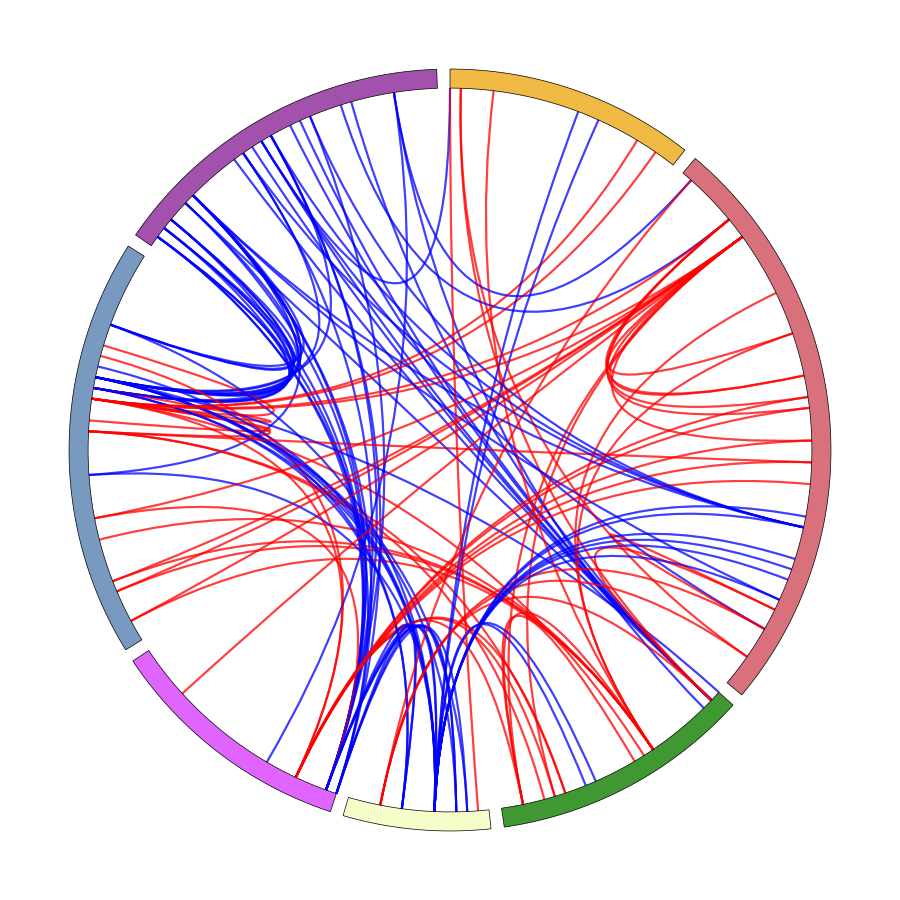

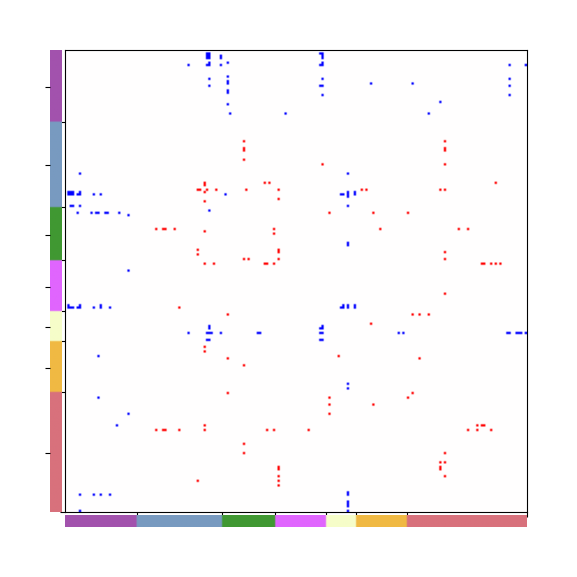

In [68]:
sectors, left_mat_df_dist = prepare_SchaeferSectors(LSchaefer, left_mat_dist, "L")
generate_circos_plot(left_mat_df_dist, sectors, rsn_colors,filepath=f'{odir}/dist_lh_FeatCircle')
plot_heatmap(left_mat_df_dist, rsn_colors,filepath=f'{odir}/dist_lh_FeatMatrix')

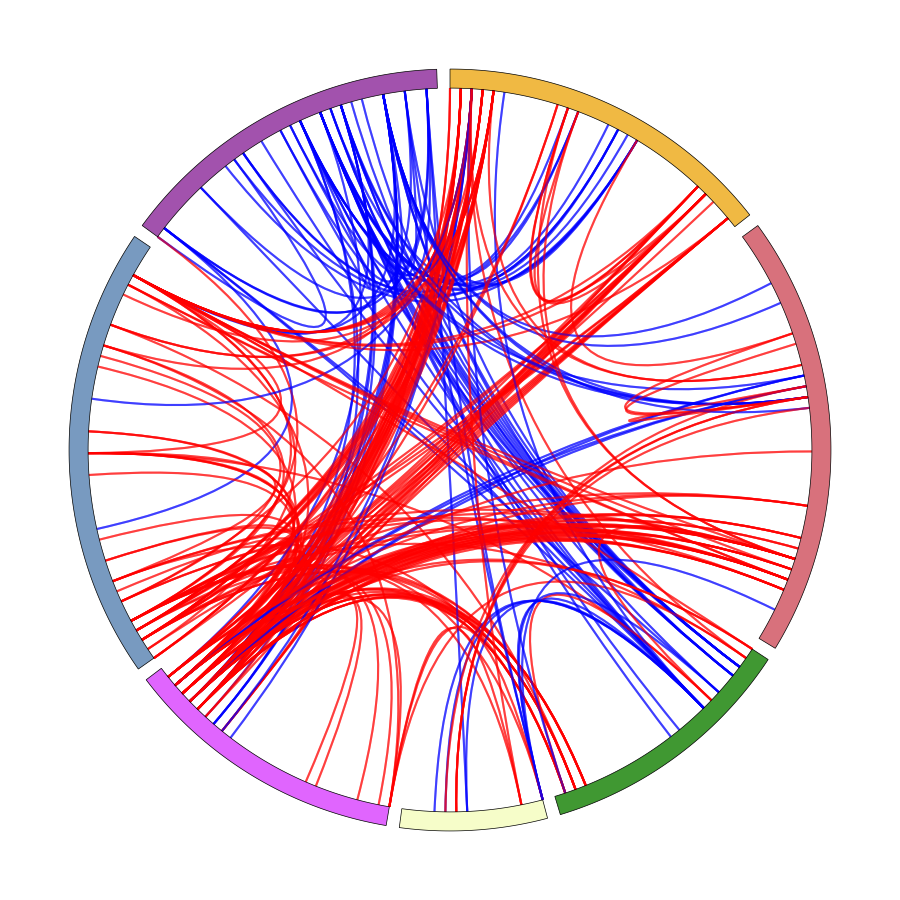

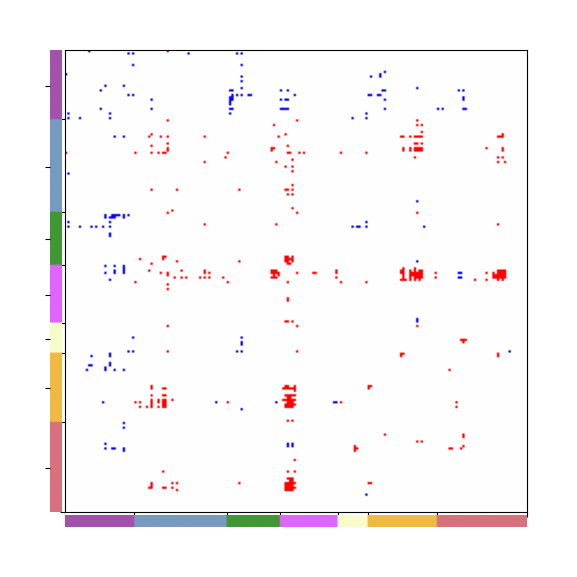

In [69]:
sectors, right_mat_df_dist = prepare_SchaeferSectors(RSchaefer, right_mat_dist, "R")
generate_circos_plot(right_mat_df_dist, sectors, rsn_colors,filepath=f'{odir}/dist_rh_FeatCircle')
plot_heatmap(right_mat_df_dist, rsn_colors,filepath=f'{odir}/dist_rh_FeatMatrix')

## FC 

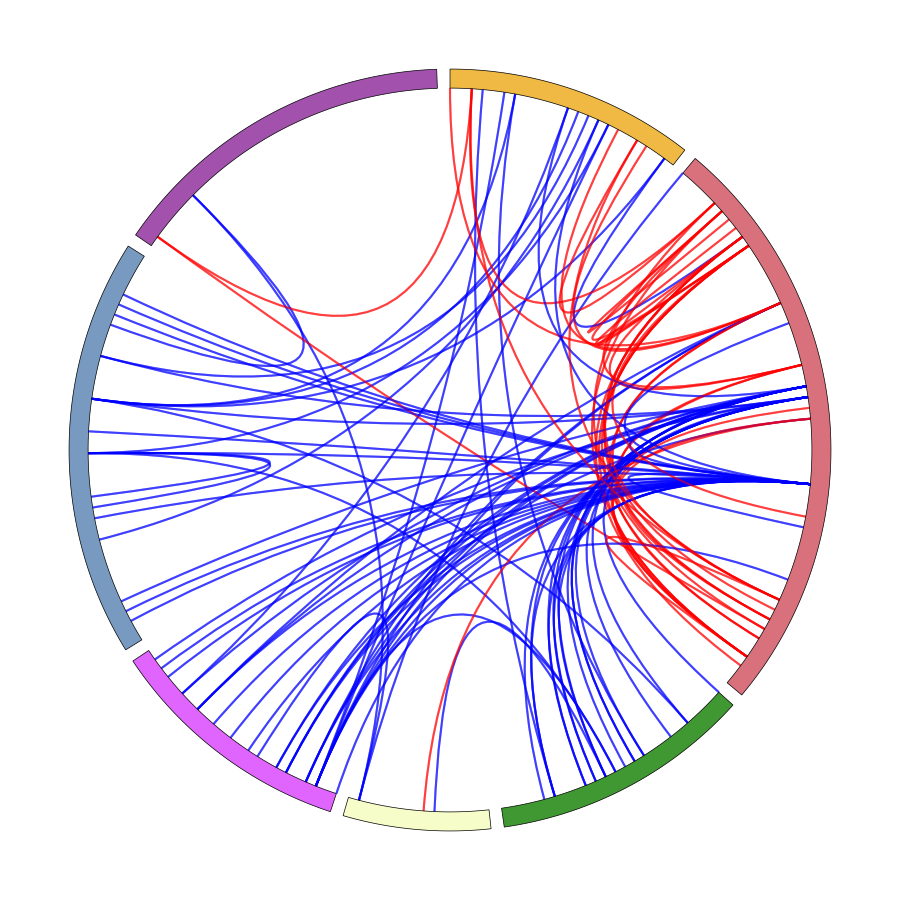

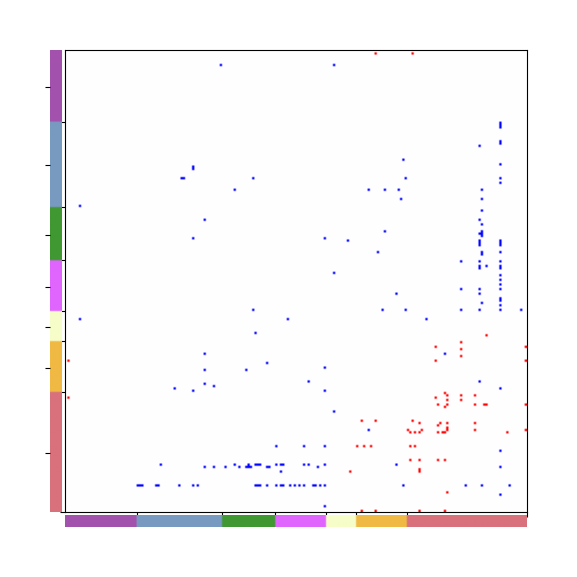

In [70]:
sectors, left_mat_df_fc = prepare_SchaeferSectors(LSchaefer, left_mat_FC, "L")
generate_circos_plot(left_mat_df_fc, sectors, rsn_colors,filepath=f'{odir}/fc_lh_FeatCircle')
plot_heatmap(left_mat_df_fc, rsn_colors,filepath=f'{odir}/fc_lh_FeatMatrix')

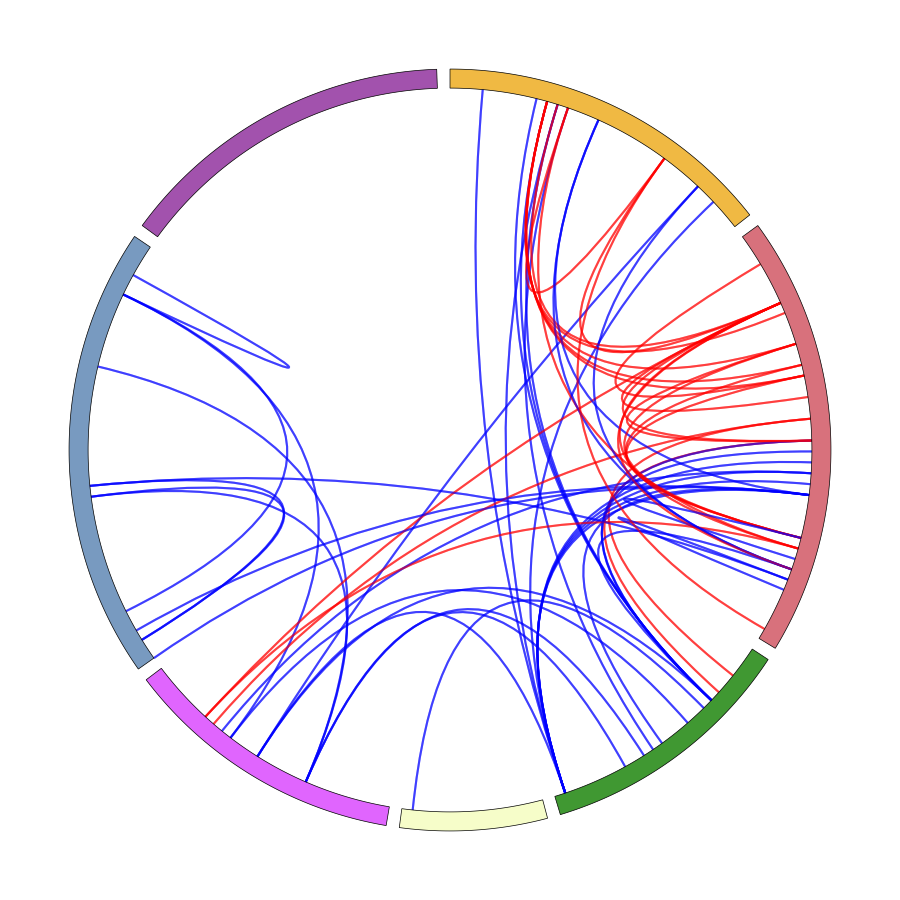

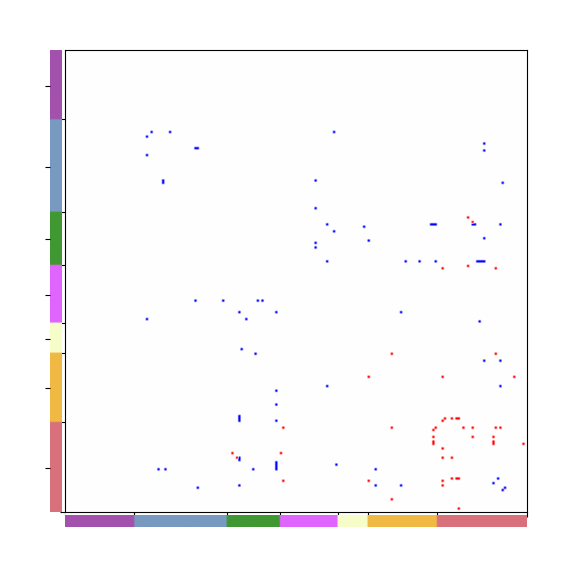

In [71]:
sectors, right_mat_df_fc = prepare_SchaeferSectors(RSchaefer, right_mat_FC, "R")
generate_circos_plot(right_mat_df_fc, sectors, rsn_colors,filepath=f'{odir}/fc_rh_FeatCircle')
plot_heatmap(right_mat_df_fc, rsn_colors,filepath=f'{odir}/fc_rh_FeatMatrix')